# Lab Week 2: Gradient Descent

## 1. Setting up your computer

Create an environment and install the dependencies, e.g. using conda:

```bash
conda create -y --name nn python=3.13
conda activate nn
conda install jupyter matplotlib numpy scikit-learn  -y
```

## 2. Importing dependencies & defining plotting functions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
np.random.seed(42)


def plot_loss():
    plt.figure()
    plt.plot(losses, color="green")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()


def plot_regression():
    plt.figure()
    plt.scatter(x, y, color="lightgreen")
    idx = np.argsort(x)
    plt.plot(x[idx], (w * x + b)[idx], color="green", linewidth=2)
    plt.title("Fitted Line")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True)
    plt.show()


def plot_decision_boundary():
    plt.figure()
    plt.contourf(xx, yy, probs, 20, cmap="Greens")
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="Greens", edgecolor="black")
    plt.title("Decision Boundary")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()


## 3. Linear Regression

Creating data

In [2]:
m = 10  # number of training examples
x = np.linspace(-3, 3, m)
slope = 2
intercept = -0.3
y = slope * x + intercept + (0.5 * np.random.randn(m))


Setting weight and bias (fixed for demonstration purpose, should be random)

In [3]:
w = -3.0
b = 5.0
lr = 0.03  # learning rate 
losses = []

Run the following cell manually a couple of times to see how the line fits the data.

Then, increase `epochs` to loop over the training (e.g. 50)

Weight: 1.9947813181203407
Bias:   0.16540563307146808
Loss:   0.17944002665430778


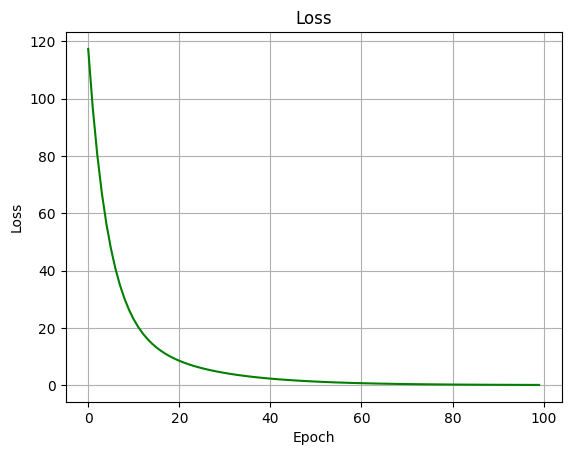

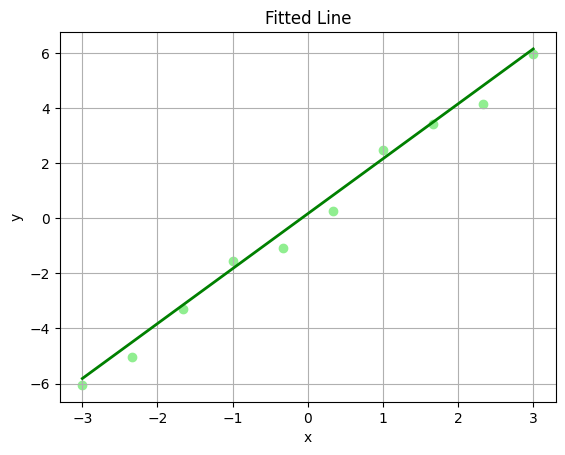

In [4]:
epochs = 100

for _ in range(epochs):
    y_hat = w * x + b
    err = y_hat - y
    loss = (err**2).mean()  # Mean Squared Error (MSE)
    losses.append(loss)
    dw = (x * err).mean()
    db = err.mean()
    w -= lr * dw
    b -= lr * db


print(f"Weight: {w}")
print(f"Bias:   {b}")
print(f"Loss:   {losses[-1]}")
plot_loss()
plot_regression()


## 4. Logistic Regression

Creating data, setting weights and bias

In [5]:
X, y = make_blobs(n_samples=10, centers=2, cluster_std=1.2)
w = np.random.rand(X.shape[1])
b = 0.111
lr = 0.03
losses = []


Definei

In [6]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def bce(a):  # Binary Cross Entropy Loss
    # 1e-12 (epsilon) added to prevent that np.log(a) or np.log(1-a) DO NOT become np.log(0) = -inf
    return -(y * np.log(a + 1e-12) + (1 - y) * np.log(1 - a + 1e-12)).mean()


Run the following cell again a couple of times manually to see the change, then increase the number of epochs

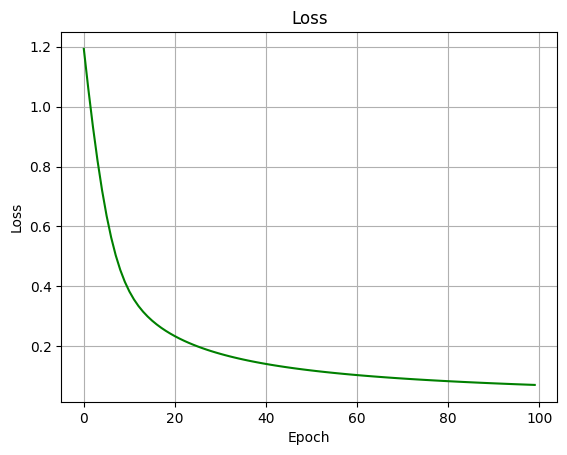

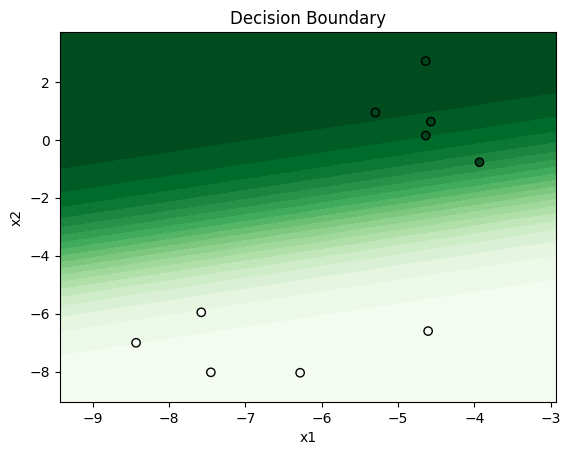

In [7]:
epochs = 100
for _ in range(epochs):
    z = X.dot(w) + b
    a = sigmoid(z)
    loss = bce(a)
    losses.append(loss)
    dw = X.T.dot(a - y) / len(X)
    db = (a - y).mean()
    w -= lr * dw
    b -= lr * db

plot_loss()

xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200),
    np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 200)
)
grid = np.c_[xx.ravel(), yy.ravel()]
probs = sigmoid(grid.dot(w) + b).reshape(xx.shape)

plot_decision_boundary()
